<a href="https://colab.research.google.com/github/dhiru69-tech/ML-Techniques-Lab-Project/blob/main/notebooks/day10_decision_tree_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 10: Decision Tree, Pruning and Tuning
**Course:** BO CDA 205, Machine Learning Techniques
**Dataset:** German Credit (1000 customers, 21 columns)
**Syllabus link:** Supervised learning, Decision Trees (controlling overfitting)

> **Goal of today:** Prune the tree, choose its settings with cross-validation on the training set only, and evaluate the final tree on the test set once.

## 1. Setup

Same workflow as before. New today: a **Pipeline** that bundles preprocessing and the tree. During cross-validation, the preprocessor is then fitted again inside each fold using only that fold's training rows, so no information leaks.

`make_pipe(**params)` builds a fresh pipeline with the tree settings we pass in.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# Load data. bad = 1 is the positive class
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
X = df.drop(columns=['class'])
y = df['class'].map({'good': 0, 'bad': 1}).astype(int)

# Stratified 80/20 split with a fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

preprocess = ColumnTransformer(
    [('num', StandardScaler(), num_cols),
     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)],
    sparse_threshold=0
)
preprocess.set_output(transform="pandas")


def make_pipe(**params):
    """Pipeline = preprocessing + decision tree. params go to the tree."""
    return Pipeline([
        ('prep', clone(preprocess)),
        ('tree', DecisionTreeClassifier(random_state=42, **params)),
    ])


def evaluate(name, y_true, pred):
    """Return the main metrics for the positive class (bad = 1)."""
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'model': name,
        'accuracy': round(accuracy_score(y_true, pred), 3),
        'precision': round(precision_score(y_true, pred, zero_division=0), 3),
        'recall': round(recall_score(y_true, pred, zero_division=0), 3),
        'f1': round(f1_score(y_true, pred, zero_division=0), 3),
        'FN': fn, 'FP': fp,
        'cost': 5 * fn + fp,          # FN costs 5, FP costs 1 (Day 8)
    }


# 5-fold cross-validation, keeping the 70/30 ratio inside every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (800, 20) | Test: (200, 20)


## 2. Pre-Pruning: `min_samples_leaf`

We make each leaf rest on more customers. For every setting we run 5-fold cross-validation **on the training set** and look at:

- **train accuracy** (inside the folds): how well the tree memorises
- **validation accuracy and F1**: how well it does on rows it has not seen

> **Reading the gap:** a big gap between train and validation accuracy means overfitting.

   min_samples_leaf  train_acc  val_acc  val_f1  val_recall
0                 1      1.000    0.670   0.465       0.479
1                 2      0.953    0.676   0.431       0.412
2                 5      0.875    0.699   0.483       0.467
3                10      0.830    0.704   0.435       0.383
4                20      0.786    0.716   0.476       0.433
5                40      0.759    0.716   0.479       0.454


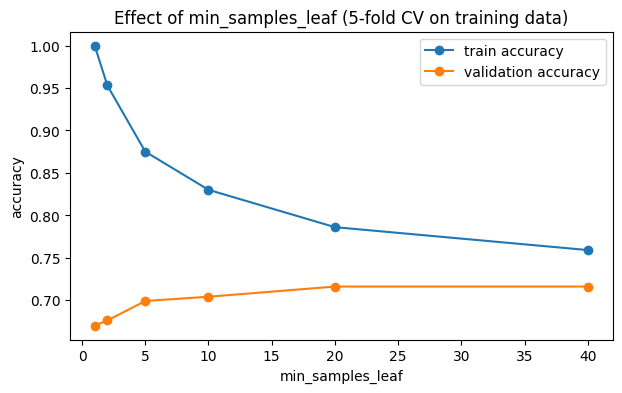

In [11]:
rows = []
for leaf in [1, 2, 5, 10, 20, 40]:
    res = cross_validate(
        make_pipe(min_samples_leaf=leaf), X_train, y_train, cv=cv,
        scoring={'acc': 'accuracy', 'f1': 'f1', 'recall': 'recall'},
        return_train_score=True
    )
    rows.append({
        'min_samples_leaf': leaf,
        'train_acc': res['train_acc'].mean(),
        'val_acc': res['test_acc'].mean(),
        'val_f1': res['test_f1'].mean(),
        'val_recall': res['test_recall'].mean(),
    })

leaf_table = pd.DataFrame(rows).round(3)
print(leaf_table)

plt.figure(figsize=(7, 4))
plt.plot(leaf_table['min_samples_leaf'], leaf_table['train_acc'], marker='o', label='train accuracy')
plt.plot(leaf_table['min_samples_leaf'], leaf_table['val_acc'], marker='o', label='validation accuracy')
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.title("Effect of min_samples_leaf (5-fold CV on training data)")
plt.legend()
plt.show()

## 3. Post-Pruning: `ccp_alpha`

We grow the full tree, ask scikit-learn for the list of useful alpha values (`cost_complexity_pruning_path`), and measure each pruned tree with cross-validation.

| alpha | Tree |
|---|---|
| 0 | full, overfitted tree |
| larger | smaller tree |
| very large | only the root |

Number of alpha values tried: 26


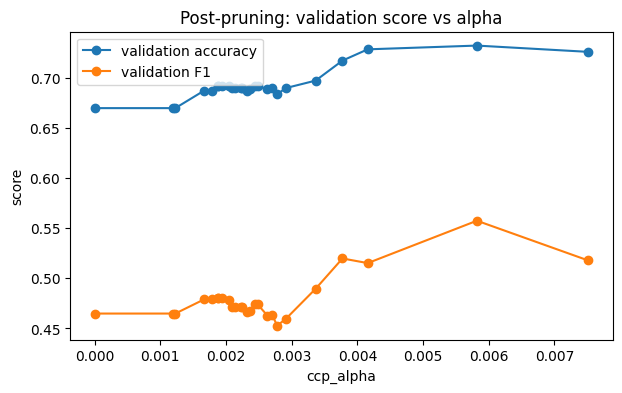

Alpha with the best validation F1: 0.00582


In [12]:
# Fit preprocessing on the training set, then ask for the pruning path
Xtr_p = clone(preprocess).fit_transform(X_train)
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(Xtr_p, y_train)

alphas = path.ccp_alphas[:-1]            # the last alpha leaves only the root
step = max(1, len(alphas) // 25)         # keep about 25 values so it runs fast
alphas = alphas[::step]
print("Number of alpha values tried:", len(alphas))

rows = []
for a in alphas:
    res = cross_validate(
        make_pipe(ccp_alpha=a), X_train, y_train, cv=cv,
        scoring={'acc': 'accuracy', 'f1': 'f1'}
    )
    rows.append({'alpha': a, 'val_acc': res['test_acc'].mean(), 'val_f1': res['test_f1'].mean()})

alpha_table = pd.DataFrame(rows)

plt.figure(figsize=(7, 4))
plt.plot(alpha_table['alpha'], alpha_table['val_acc'], marker='o', label='validation accuracy')
plt.plot(alpha_table['alpha'], alpha_table['val_f1'], marker='o', label='validation F1')
plt.xlabel("ccp_alpha")
plt.ylabel("score")
plt.title("Post-pruning: validation score vs alpha")
plt.legend()
plt.show()

best_alpha = alpha_table.loc[alpha_table['val_f1'].idxmax(), 'alpha']
print("Alpha with the best validation F1:", round(best_alpha, 5))

## 4. Grid Search with Cross-Validation

We try every combination of these settings. Each one is scored with 5-fold CV on the **training set**.

| Setting | Values tried |
|---|---|
| `max_depth` | 2, 3, 4, 5, 6, 8, None |
| `min_samples_leaf` | 1, 5, 10, 20 |
| `criterion` | gini, entropy |
| `class_weight` | None, balanced |

**Scoring = F1** for the bad class, because accuracy alone is misleading on 70/30 data.

In [13]:
param_grid = {
    'tree__max_depth': [2, 3, 4, 5, 6, 8, None],
    'tree__min_samples_leaf': [1, 5, 10, 20],
    'tree__criterion': ['gini', 'entropy'],
    'tree__class_weight': [None, 'balanced'],
}

grid = GridSearchCV(
    make_pipe(), param_grid,
    scoring='f1', cv=cv, n_jobs=-1, refit=True
)
grid.fit(X_train, y_train)

print("Best settings:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

# Top 5 combinations
results = pd.DataFrame(grid.cv_results_)
cols = ['param_tree__max_depth', 'param_tree__min_samples_leaf',
        'param_tree__criterion', 'param_tree__class_weight',
        'mean_test_score', 'rank_test_score']
print(results.sort_values('rank_test_score')[cols].head(5).round(3).to_string(index=False))

Best settings: {'tree__class_weight': 'balanced', 'tree__criterion': 'entropy', 'tree__max_depth': 8, 'tree__min_samples_leaf': 1}
Best cross-validated F1: 0.572
param_tree__max_depth  param_tree__min_samples_leaf param_tree__criterion param_tree__class_weight  mean_test_score  rank_test_score
                    8                             1               entropy                 balanced            0.572                1
                    4                             1               entropy                 balanced            0.566                2
                    3                             1               entropy                 balanced            0.566                3
                    5                             1                  gini                 balanced            0.562                4
                    3                            20               entropy                 balanced            0.561                5


## 5. Final Evaluation on the Test Set (once)

The best tree from the grid search is now evaluated on the **untouched test set**. We compare it with:

- the **baseline** (always predict good)
- the **unpruned tree** from Day 9

> **Cost** = 5 x FN + FP (Day 8). Lower is better.
>
> **Rule:** after seeing this result we do **not** go back and re-tune. If we did, the test set would become part of training and stop being a fair final exam.

In [14]:
from sklearn.dummy import DummyClassifier

best_tree = grid.best_estimator_                  # pipeline with the winning settings
full_tree = make_pipe().fit(X_train, y_train)     # no limits (Day 9 style)
baseline = Pipeline([('prep', clone(preprocess)),
                     ('dummy', DummyClassifier(strategy='most_frequent'))]).fit(X_train, y_train)

final = pd.DataFrame([
    evaluate('baseline (always good)', y_test, baseline.predict(X_test)),
    evaluate('unpruned tree', y_test, full_tree.predict(X_test)),
    evaluate('tuned tree', y_test, best_tree.predict(X_test)),
])
print(final)

                    model  accuracy  precision  recall     f1  FN  FP  cost
0  baseline (always good)      0.70      0.000   0.000  0.000  60   0   300
1           unpruned tree      0.62      0.371   0.383  0.377  37  39   224
2              tuned tree      0.63      0.419   0.600  0.493  24  50   170


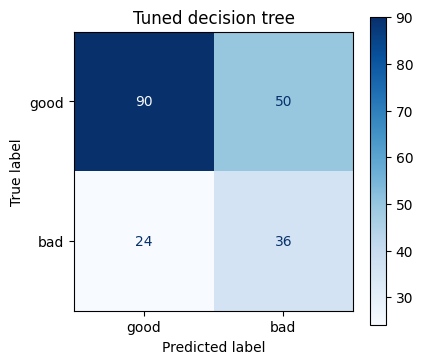

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_tree.predict(X_test),
    display_labels=['good', 'bad'], cmap='Blues', ax=ax
)
plt.title("Tuned decision tree")
plt.show()

## 6. Reading the Tree in Real Units

On Day 9 the numeric thresholds looked odd (for example `duration <= 0.12`) because they were **scaled values**.

A tree does **not need scaling**: scaling only stretches each feature, so the best split points are the same, just written in different units. We prove it by building a tree on **unscaled** numeric columns, whose thresholds are readable.

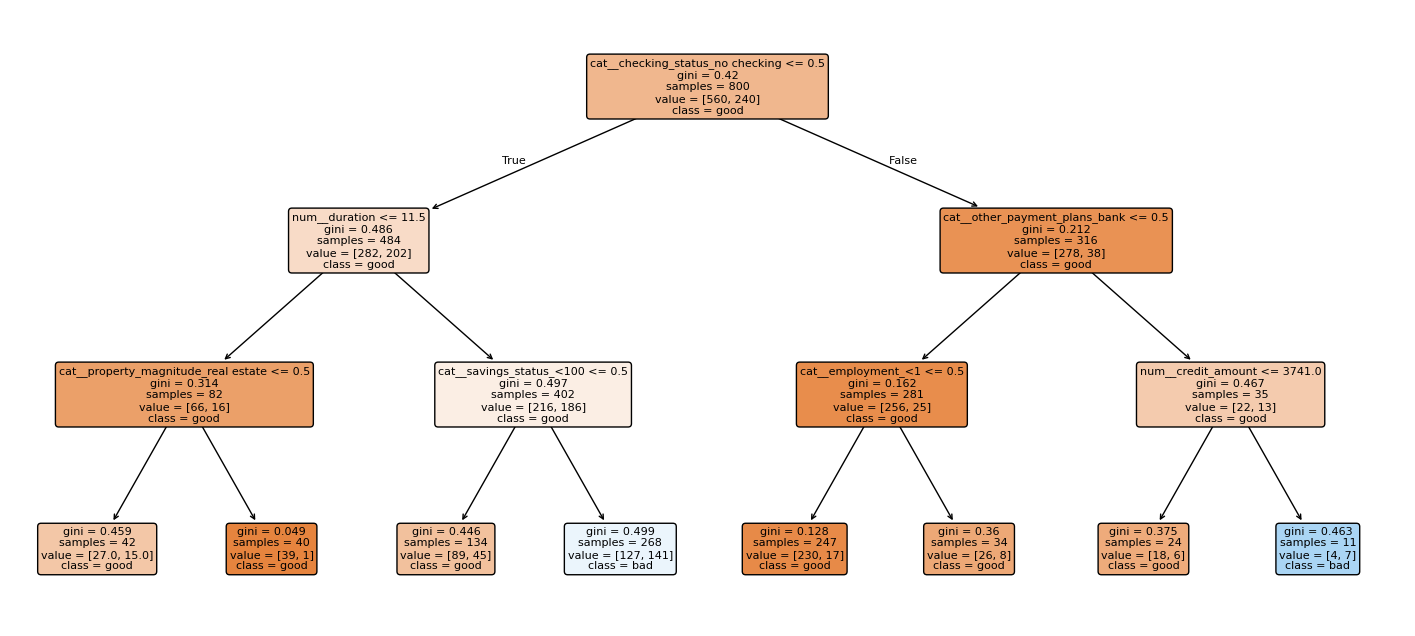

|--- cat__checking_status_no checking <= 0.50
|   |--- num__duration <= 11.50
|   |   |--- cat__property_magnitude_real estate <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__property_magnitude_real estate >  0.50
|   |   |   |--- class: 0
|   |--- num__duration >  11.50
|   |   |--- cat__savings_status_<100 <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__savings_status_<100 >  0.50
|   |   |   |--- class: 1
|--- cat__checking_status_no checking >  0.50
|   |--- cat__other_payment_plans_bank <= 0.50
|   |   |--- cat__employment_<1 <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__employment_<1 >  0.50
|   |   |   |--- class: 0
|   |--- cat__other_payment_plans_bank >  0.50
|   |   |--- num__credit_amount <= 3741.00
|   |   |   |--- class: 0
|   |   |--- num__credit_amount >  3741.00
|   |   |   |--- class: 1



In [16]:
# Same preprocessing, but numeric columns are passed through unscaled
prep_raw = ColumnTransformer(
    [('num', 'passthrough', num_cols),
     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)],
    sparse_threshold=0
)
prep_raw.set_output(transform="pandas")

Xtr_raw = prep_raw.fit_transform(X_train)
Xte_raw = prep_raw.transform(X_test)

# Tuned settings, but with a depth cap of 3 so the picture stays readable
tree_raw = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
tree_raw.fit(Xtr_raw, y_train)

plt.figure(figsize=(18, 8))
plot_tree(tree_raw, feature_names=Xtr_raw.columns, class_names=['good', 'bad'],
          filled=True, rounded=True, fontsize=8)
plt.show()

# The same tree as plain-text rules
print(export_text(tree_raw, feature_names=list(Xtr_raw.columns)))

In [17]:
# Compare with a scaled-data tree of the same settings
tree_scaled = make_pipe(max_depth=3, min_samples_leaf=10).fit(X_train, y_train)

same = (tree_scaled.predict(X_test) == tree_raw.predict(Xte_raw)).mean()
print("Share of test predictions that are identical:", round(same, 3))

Share of test predictions that are identical: 1.0


## 7. Decision Tree: Summary

| Strengths | Weaknesses |
|---|---|
| easy to explain and draw | overfits quickly without limits |
| needs no scaling | small changes in data can change the whole tree |
| handles numeric and categorical features | splits are axis-aligned only |
| shows which features matter | usually less accurate than ensembles |

**Hyperparameters that control it:** `max_depth`, `min_samples_leaf`, `min_samples_split`, `ccp_alpha`, `criterion`, `class_weight`.